In [11]:
# We will now be importing some required libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

#Loading the dataset
dataset = pd.read_csv('drive/MyDrive/SEIS763ML/DataML/carPurchase.csv')

In [12]:
X = dataset.iloc[:,[2,3]].values
y = dataset.iloc[:,4].values

In [13]:
#Splitting the data into Training Set and Test Set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, stratify=y)


In [14]:
#Normalizing the features
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)

#Fitting Logistic Regression to Training Set
from sklearn.linear_model import LogisticRegression
classifierObj = LogisticRegression()
classifierObj.fit(X_train, y_train)

LogisticRegression()

In [15]:
#Making predictions on the Test Set
y_pred = classifierObj.predict(X_test)

In [16]:
#Predicting probabilities
y_pred_prob = classifierObj.predict_proba(X_test)

In [17]:
#Print Model Accuracy
print(classifierObj.score(X_test,y_test))

0.8083333333333333


In [18]:
#Evaluating the predictions using a Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

#Print the classification report
from sklearn.metrics import classification_report
report = classification_report(y_test, y_pred)
print(report)

[[72  5]
 [18 25]]
              precision    recall  f1-score   support

           0       0.80      0.94      0.86        77
           1       0.83      0.58      0.68        43

    accuracy                           0.81       120
   macro avg       0.82      0.76      0.77       120
weighted avg       0.81      0.81      0.80       120



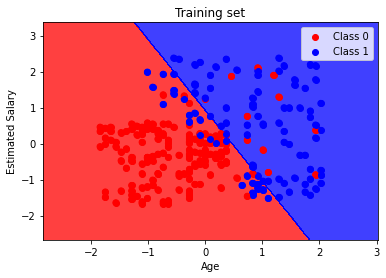

In [19]:
# Visualizing the Training set results
from matplotlib.colors import ListedColormap
X_set, y_set = X_train, y_train
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                        np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))
plt.contourf(X1, X2, classifierObj.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
                alpha = 0.75, cmap = ListedColormap(('red', 'blue')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
plt.scatter(X_set[:, 0], X_set[:, 1], c=y_set, cmap=ListedColormap(('red', 'blue')))
plt.scatter(X_set[y_set == 0, 0], X_set[y_set == 0, 1], color = 'red', label = 'Class 0')
plt.scatter(X_set[y_set == 1, 0], X_set[y_set == 1, 1], color = 'blue', label = 'Class 1')
plt.title('Training set')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

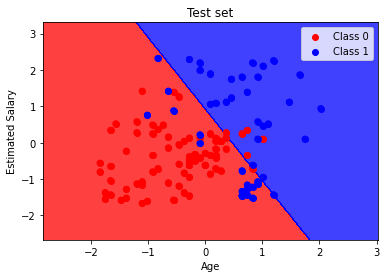

In [20]:
# Visualizing the Test set results
from matplotlib.colors import ListedColormap
X_set, y_set = X_test, y_test
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))
plt.contourf(X1, X2, classifierObj.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'blue')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
plt.scatter(X_set[:, 0], X_set[:, 1], c=y_set, cmap=ListedColormap(('red', 'blue')))
plt.scatter(X_set[y_set == 0, 0], X_set[y_set == 0, 1], color = 'red', label = 'Class 0')
plt.scatter(X_set[y_set == 1, 0], X_set[y_set == 1, 1], color = 'blue', label = 'Class 1')
plt.title('Test set')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()